In [5]:
import os,sys
sys.path.append("Light-GCOT-main/")
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scanpy as sc
import numpy as np
import torch
import torch.nn as nn
import wandb
import moscot.plotting as mtp
import scipy
from torch.utils.data import DataLoader
from tqdm import tqdm

from moscot import datasets
from moscot.problems.cross_modality import TranslationProblem
from sklearn import preprocessing as pp

from src.samplers.from_dataset import DatasetSampler
from src.samplers.from_loader import PairedLoaderSampler
from torch.utils.data import DataLoader, TensorDataset
from src.samplers.primary import StandardNormalSampler, SwissRollSampler
from src.models.light_gcot import LightGCOT
from src.utils.datasets import (
    get_Splatter_data,
    get_Splatter_dataset,
    get_Splatter_samplers,
)
from src.utils.plotting.matplotlib import plot_A_parameters, plot_PCA

#https://moscot.readthedocs.io/en/latest/notebooks/tutorials/600_tutorial_translation.html

## Define the metric - FOSCTTM (“Fractions of Samples Closer to the True Match”)

In [6]:
def foscttm(
    x: np.ndarray,
    y: np.ndarray,
) -> float:
    d = scipy.spatial.distance_matrix(x, y)
    foscttm_x = (d < np.expand_dims(np.diag(d), axis=1)).mean(axis=1)
    foscttm_y = (d < np.expand_dims(np.diag(d), axis=0)).mean(axis=0)
    fracs = []
    for i in range(len(foscttm_x)):
        fracs.append((foscttm_x[i] + foscttm_y[i]) / 2)
    return np.mean(fracs).round(4)

In [7]:
adata_atac = datasets.bone_marrow(rna=False)
adata_rna = datasets.bone_marrow(rna=True)
adata_atac, adata_rna

(AnnData object with n_obs × n_vars = 6224 × 8000
     obs: 'ATAC_nCount_peaks', 'ATAC_nucleosome_signal', 'cell_type', 'batch'
     uns: 'cell_type_colors', 'neighbors'
     obsm: 'ATAC_lsi_full', 'ATAC_lsi_red', 'X_umap', 'geneactivity_scvi'
     layers: 'counts'
     obsp: 'connectivities', 'distances',
 AnnData object with n_obs × n_vars = 6224 × 2000
     obs: 'GEX_n_counts', 'GEX_n_genes', 'cell_type', 'batch'
     uns: 'cell_type_colors', 'neighbors'
     obsm: 'GEX_X_pca', 'X_umap', 'geneactivity_scvi'
     layers: 'counts'
     obsp: 'connectivities', 'distances')

In [8]:
adata_atac.obsm["ATAC_lsi_l2_norm"] = pp.normalize(
    adata_atac.obsm["ATAC_lsi_red"], norm="l2"
)

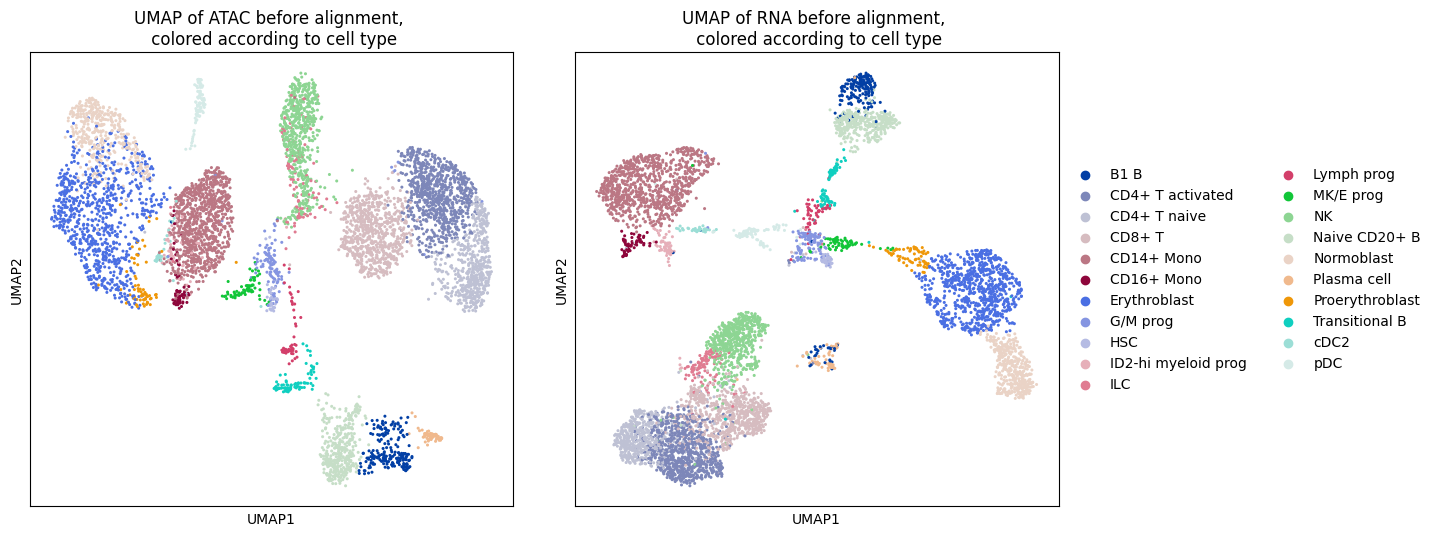

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(adata_atac, color="cell_type", ax=ax1, show=False)
ax1.legend().remove()
ax1.set_title(
    "UMAP of ATAC before alignment, \n colored according to cell type"
)
sc.pl.umap(adata_rna, color="cell_type", ax=ax2, show=False)
ax2.set_title(
    "UMAP of RNA before alignment, \n colored according to cell type"
)
plt.tight_layout(pad=3.0)
plt.show()

In [7]:
tp = TranslationProblem(adata_src=adata_atac, adata_tgt=adata_rna)
tp = tp.prepare(src_attr="ATAC_lsi_l2_norm", tgt_attr="GEX_X_pca")

In [8]:
tp = tp.solve(alpha=1.0, epsilon=1e-3)

INFO     Solving `1` problems                                                                                      
INFO     Solving problem OTProblem[stage='prepared', shape=(6224, 6224)].                                          


An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [9]:
translated = tp.translate(source="src", target="tgt", forward=True)

In [10]:
adata_rna.obsm["GEX_X_pca"].shape,  adata_atac.obsm['ATAC_lsi_l2_norm'].shape

((6224, 50), (6224, 38))

In [11]:
adata_atac.obsm['ATAC_lsi_l2_norm'].shape

(6224, 38)

In [12]:
print(
    "Average FOSCTTM score of translating ATAC onto RNA: ",
    foscttm(adata_rna.obsm["GEX_X_pca"], translated),
)

Average FOSCTTM score of translating ATAC onto RNA:  0.4686


In [9]:
adata = sc.concat(
    [adata_atac, adata_rna],
    join="outer",
    label="batch",
    keys=["ATAC (translated)", "RNA"],
)
adata.obsm["X_translated_1"] = np.concatenate(
    (translated, adata_rna.obsm["GEX_X_pca"]), axis=0
)
sc.pp.neighbors(adata, use_rep="X_translated_1")
sc.tl.umap(adata)

/home/jovyan/.local/lib/python3.10/site-packages/anndata/_core/anndata.py:1818: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


NameError: name 'translated' is not defined

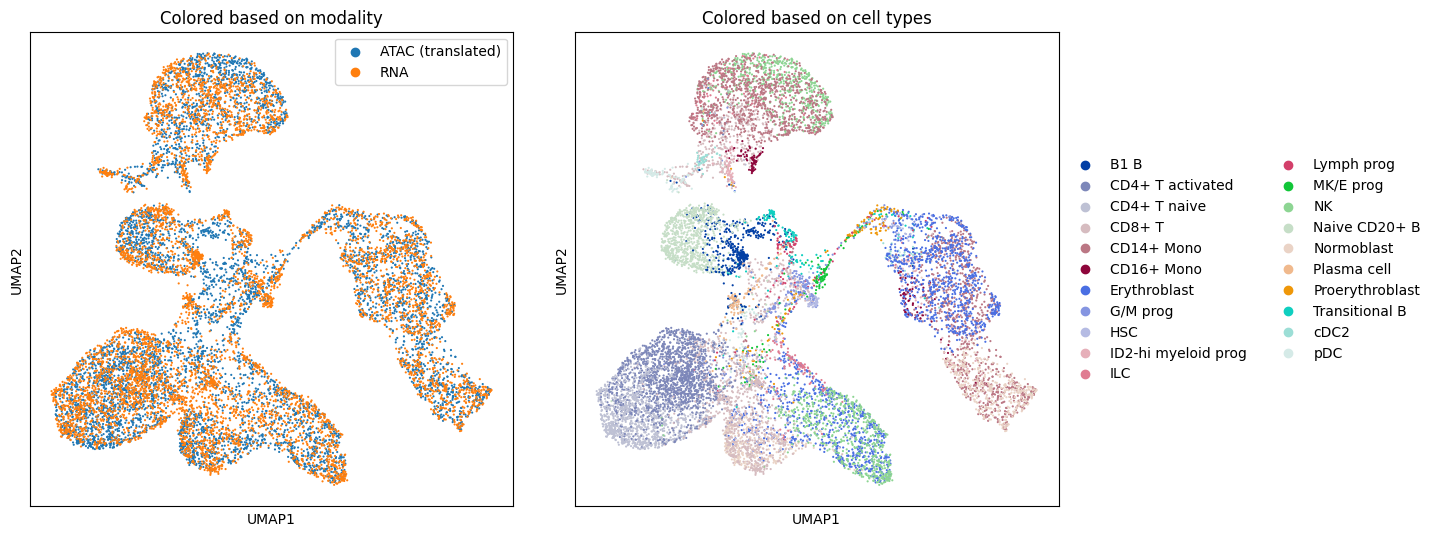

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
sc.pl.umap(adata, color=["batch"], ax=ax1, show=False)
ax1.legend()
ax1.set_title("Colored based on modality")
sc.pl.umap(adata, color=["cell_type"], ax=ax2, show=False)
ax2.set_title("Colored based on cell types")
plt.tight_layout(pad=3.0)
plt.show()

## Our Method

In [10]:
@torch.no_grad()
def draw_target(z0, z1, traj_plot=100, y1=None):
    plt.figure(figsize=(6,6))
    #plt.xlim(-5, 2)
    #plt.ylim(-3.5, 3.5)

    plt.scatter(z0[:, 0], z0[:, 1], label=r'$\pi_0 (Target)$', alpha=0.9, edgecolors='black', c='violet')
    plt.scatter(z1[:, 0], z1[:, 1], label=r'$\pi_1 (Generated)$', alpha=0.6, edgecolors='black', c='black')
    if y1 is not None:
        plt.scatter(y1[:, 0], y1[:, 1], label=r'$\T$', alpha=0.5, edgecolors='black', c='black')
    #plt.scatter(traj[-1][:, 0].cpu().numpy(), traj[-1][:, 1].cpu().numpy(), label='Generated', alpha=0.3, c='violet')
    plt.legend()
    plt.title('Distribution')
    plt.grid()
    plt.tight_layout()
    assert traj_plot<=len(z0)
    for i in range(traj_plot):
        x_values = [z0[i,0], z1[i,0]]
        y_values = [z0[i,1], z1[i,1]]
        plt.plot(x_values, y_values, c='slateblue', alpha=0.3)
        plt.title('Transport Trajectory')
        plt.tight_layout()

In [11]:
source_data = adata_rna.obsm["GEX_X_pca"]
target_data = adata_atac.obsm['ATAC_lsi_l2_norm']
X_DIM = source_data.shape[1]
Y_DIM = target_data.shape[1]
#X_DIM = data_set["features"].shape[1]
#Y_DIM = data_set["features"].shape[1]
assert X_DIM > 1
assert Y_DIM > 1

OUTPUT_SEED = 42

N_POTENTIALS = 10
M_POTENTIALS = 1 #10
EPSILON = 0.002
A_DIAGONAL_INIT = 0.5
L_PAIRED_SAMPLES = 100
M_X_UNPAIRED_SAMPLES = 0
N_Y_UNPAIRED_SAMPLES = 0

BATCH_SIZE = 128
SAMPLING_BATCH_SIZE = 128

D_LR = 3e-4  # 1e-3 for eps 0.1, 0.01 and 3e-4 for eps 0.002
D_GRADIENT_MAX_NORM = float("inf")

NUM_LABELED = 10
TRAIN_SUBSET_SIZE = 2

PLOT_EVERY = 1000
MAX_STEPS = 20000
CONTINUE = -1

In [12]:
EXP_COST = "MLP"
EXP_COST_INCLUDED = True
EXP_META_INFO = ""
EXP_NAME = (
    f"Light-GCOT_Batch_Effect_"
    + f"EPSILON_{EPSILON}_"
    + f"N_{N_POTENTIALS}_"
    + f"M_{M_POTENTIALS}_"
    + f"with_{EXP_COST}_"
    + f"cost_included_{EXP_COST_INCLUDED}_"
    + f"N_PAIRED_{NUM_LABELED}_"
    + f"M_UNPAIRED_{len(source_data)}_"
    + EXP_META_INFO
)
OUTPUT_PATH = "../checkpoints/{}".format(EXP_NAME)

config = dict(
    X_DIM=X_DIM,
    Y_DIM=Y_DIM,
    D_LR=D_LR,
    BATCH_SIZE=BATCH_SIZE,
    EPSILON=EPSILON,
    D_GRADIENT_MAX_NORM=D_GRADIENT_MAX_NORM,
    N_POTENTIALS=N_POTENTIALS,
    M_POTENTIALS=M_POTENTIALS,
    A_DIAGONAL_INIT=A_DIAGONAL_INIT,
    N_PAIRED_SAMPLES=NUM_LABELED,
    M_UNPAIRED_SAMPLES=len(source_data),
)

if not os.path.exists(OUTPUT_PATH):
    os.makedirs(OUTPUT_PATH)

In [13]:
torch.manual_seed(OUTPUT_SEED)
np.random.seed(OUTPUT_SEED)

In [14]:
loader_kwargs = {"num_workers": 0, "pin_memory": True, "generator": torch.Generator(device='cpu')}
source_loader = DataLoader(source_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, **loader_kwargs)

target_loader = DataLoader(target_data, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, **loader_kwargs)
target_test_loader = DataLoader(target_data, batch_size=BATCH_SIZE, shuffle=False, drop_last=False, **loader_kwargs)

In [23]:
len(source_data)

6224

In [24]:
L_PAIRED_SAMPLES = 200
paired_indices = np.random.choice(len(source_data), size=L_PAIRED_SAMPLES, replace=False)
paired_mask = np.zeros(len(source_data), dtype=bool)
paired_mask[paired_indices] = True

full_test = torch.tensor(source_data)

PSD = torch.tensor(source_data[paired_mask])
PTD = torch.tensor(target_data[paired_mask])
USD = torch.tensor(source_data[~paired_mask])
UTD = torch.tensor(target_data[~paired_mask])
num_unpaired = len(USD)//2
test_size = L_PAIRED_SAMPLES//2

In [57]:
print(paired_indices)
print(torch.tensor(source_data).shape)

[6071 1397 5476 4305 4520 5965 3850 4540 4363 1751 5818 5484 4500 6028
 2712  540 1668 5143 3914 3819 1809 5987 2037 5398 5966 1134 4594 5627
  754  298  863 1370  948 3815 1841 1189 1174 1926 4504 4706 1785 5427
 4629 5678 5078  585 2494 4117 4138  189 4975  282 5094  285  336 4916
 3094 2273 2540 1856 6034 2922 5006  117 1166 4640 2040 4068 5054 3750
 2490 2681 1631 5777 2643  843 5873 4084 5223 3208 5383 5536 1825 4538
 2322  967  183 2097  306  890 6168 4888 4638 2629 2745 6030  325 2433
 3268 2480 2076 4102 2675 5822 5104 6081 5667 4938 5653 4283 5009 3263
 2229 4212 5982 2104 3087 3536 2894 5119 5004 2240 3401 4767 5679 1181
 3414  865 4987  847 1137 3757 4154 4172 6017 5479 5333 1888 4205 4573
  469 4936 5778 5061 2786 2666 1594  149   61 4795 4029 2812 3175 5167
 3126  310 5588 3148 3262 3946 4436 5330 4489 2989 1243 2842 2835 1739
 2519 4982 3040 4124 4005 2608   22 1821 6185 1788 2391 3625 4499 2884
 2182  281 2672  489 4082 3771  991 1499 5758  123 5936 2809 1530 4352
 6214 

In [58]:
X_A = USD[:num_unpaired]
X_B = USD[num_unpaired:]
Y_A = UTD[:num_unpaired]
Y_B = UTD[num_unpaired:]
X_C = PSD[:test_size]
Y_C = PTD[:test_size]
X_C_test = PSD[test_size:]
Y_C_test = PTD[test_size:]

paired_loader = DataLoader(
    TensorDataset(PSD, PTD),
    batch_size=min(BATCH_SIZE, L_PAIRED_SAMPLES),
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
pd_sampler = PairedLoaderSampler(paired_loader, device='cpu')
usd_sampler = DatasetSampler(X_A, device='cpu')
utd_sampler = DatasetSampler(Y_B, device='cpu')

print(PTD.shape)
print(UTD.shape)
utd_sampler.sample(1).shape

torch.Size([200, 38])
torch.Size([6024, 38])


torch.Size([1, 38])

In [42]:
D = LightGCOT(
    x_dim=X_DIM,
    y_dim=Y_DIM,
    n_potentials=N_POTENTIALS,
    m_potentials=M_POTENTIALS,
    epsilon=EPSILON,
    sampling_batch_size=SAMPLING_BATCH_SIZE,
    A_diagonal_init=A_DIAGONAL_INIT,
    cost_function=EXP_COST,
)

D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)

if CONTINUE > -1:
    D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{CONTINUE}.pt")))

In [16]:
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=50)
X_tsne = tsne.fit_transform(X_C_test)
Y_tsne = tsne.fit_transform(Y_C_test)

In [4]:
for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
    # training loop
    D_opt.zero_grad()

    X = usd_sampler.sample(BATCH_SIZE)
    Y = utd_sampler.sample(BATCH_SIZE)
    
    log_v_m = D.compute_log_v_m(X)  # [bs x M]
    b_m = D.compute_b_m(X)  # [bs x M x y_dim]

    log_w_n = D.compute_log_w_n()  # [N]
    a_n = D.compute_a_n()  # [N x y_dim]
    A_n = D.compute_A_n()  # [N x y_dim]

    f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m, b_m)
    f = D.compute_primal_potential(Y, log_w_n, a_n, A_n)

    if EXP_COST_INCLUDED:
        X_paired, Y_paired = pd_sampler.sample(BATCH_SIZE)
        log_v_m_paired = D.compute_log_v_m(X_paired)  # [bs x M]
        b_m_paired = D.compute_b_m(X_paired)  # [bs x M x y_dim]

        c = D.compute_cost(Y_paired, log_v_m_paired, b_m_paired)
        D_loss = c.mean() - (f_c + f).mean()
        D_loss.backward()
        #wandb.log({r"$c(x, y)$": c.mean().item()}, step=step)
    else:
        D_loss = -(f_c + f).mean()
        D_loss.backward()
    D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
    D_opt.step()

    # wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
    # wandb.log({f"D_loss": D_loss.item()}, step=step)
    # wandb.log({r"$-f^c(x)$": -f_c.mean().item()}, step=step)
    # wandb.log({r"$-f(y)$": -f.mean().item()}, step=step)
    # wandb.log({r"$-f(y)-f^c(x)$": -(f_c + f).mean().item()}, step=step)
    # wandb.log({f"lam_min(A_n)": torch.min(A_n)}, step=step)
    # wandb.log({f"lam_max(A_n)": torch.max(A_n)}, step=step)

    if step % PLOT_EVERY == 0:
        print('D-loss', D_loss.item())
        translated = D(X_C_test)
        #translated = D(USD)
        T_tsne = tsne.fit_transform(translated)
        #print('Real matching')
        #draw_target(X_tsne, Y_tsne, traj_plot=20)
        print('Generated matching')
        draw_target(X_tsne, T_tsne, traj_plot=20)
        plt.show()

        #translated = D(USD)
        print(
            "Average FOSCTTM score of translating ATAC onto RNA: ",
            foscttm(Y_C_test, translated),
        )
        #A_dict = plot_A_parameters(D, log=True)
        #B_dict = plot_B_parameters(D, starting_points, log=True)
        #distr_dict = plot_distributions(D, X_sampler, Y_sampler, X_paired, Y_paired, starting_points, log=True)
        #wandb.log(A_dict | B_dict | distr_dict)

        #torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{step}.pt"))
        #torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{step}.pt"))

#torch.save(D.state_dict(), os.path.join(OUTPUT_PATH, f"D_{MAX_STEPS}.pt"))
#torch.save(D_opt.state_dict(), os.path.join(OUTPUT_PATH, f"D_opt_{MAX_STEPS}.pt"))

#wandb.finish()

NameError: name 'CONTINUE' is not defined

## Ablation Study

In [ ]:
#wandb.init(name=EXP_NAME, config=config)
L_PAIRED_SAMPLES_ = [5, 10, 20, 30, 40, 50, 100, 200]
results_df = pd.DataFrame(columns=['L_PAIRED_SAMPLES', 'FOSCTTM_Score'])
MAX_STEPS = 10000
for L_PAIRED_SAMPLES in L_PAIRED_SAMPLES_:
    test_size = L_PAIRED_SAMPLES+100
    print("Training with number of labeled:", L_PAIRED_SAMPLES)
    paired_indices = np.random.choice(len(source_data), size=L_PAIRED_SAMPLES+100, replace=False)
    paired_mask = np.zeros(len(source_data), dtype=bool)
    paired_mask[paired_indices] = True
    
    PSD = torch.tensor(source_data[paired_mask])
    PTD = torch.tensor(target_data[paired_mask])
    USD = torch.tensor(source_data[~paired_mask])
    UTD = torch.tensor(target_data[~paired_mask])
    num_unpaired = len(USD)//2
    test_size = L_PAIRED_SAMPLES//2
    
    X_A = USD[:num_unpaired]
    X_B = USD[num_unpaired:]
    Y_A = UTD[:num_unpaired]
    Y_B = UTD[num_unpaired:]
    X_C = PSD[:L_PAIRED_SAMPLES]
    Y_C = PTD[:L_PAIRED_SAMPLES]
    X_C_test = PSD[L_PAIRED_SAMPLES:]
    Y_C_test = PTD[L_PAIRED_SAMPLES:]
    
    paired_loader = DataLoader(
        TensorDataset(X_C, Y_C),
        batch_size=min(BATCH_SIZE, L_PAIRED_SAMPLES),
        shuffle=True,
        drop_last=True,
        **loader_kwargs,
    )
    pd_sampler = PairedLoaderSampler(paired_loader, device='cpu')
    usd_sampler = DatasetSampler(X_A, device='cpu')
    utd_sampler = DatasetSampler(Y_B, device='cpu')
    
    D = LightGCOT(
        x_dim=X_DIM,
        y_dim=Y_DIM,
        n_potentials=N_POTENTIALS,
        m_potentials=M_POTENTIALS,
        epsilon=EPSILON,
        sampling_batch_size=SAMPLING_BATCH_SIZE,
        A_diagonal_init=A_DIAGONAL_INIT,
        cost_function=EXP_COST,
    )
    
    D_opt = torch.optim.Adam(D.parameters(), lr=D_LR)
    
    if CONTINUE > -1:
        D_opt.load_state_dict(torch.load(os.path.join(OUTPUT_PATH, f"D_opt_{CONTINUE}.pt")))
        
    for step in tqdm(range(CONTINUE + 1, MAX_STEPS)):
        # training loop
        D_opt.zero_grad()
    
        X = usd_sampler.sample(BATCH_SIZE)
        Y = utd_sampler.sample(BATCH_SIZE)
        
        log_v_m = D.compute_log_v_m(X)  # [bs x M]
        b_m = D.compute_b_m(X)  # [bs x M x y_dim]
    
        log_w_n = D.compute_log_w_n()  # [N]
        a_n = D.compute_a_n()  # [N x y_dim]
        A_n = D.compute_A_n()  # [N x y_dim]
    
        f_c = D.compute_dual_potential(log_w_n, a_n, A_n, log_v_m, b_m)
        f = D.compute_primal_potential(Y, log_w_n, a_n, A_n)
    
        if EXP_COST_INCLUDED:
            X_paired, Y_paired = pd_sampler.sample(BATCH_SIZE)
            log_v_m_paired = D.compute_log_v_m(X_paired)  # [bs x M]
            b_m_paired = D.compute_b_m(X_paired)  # [bs x M x y_dim]
    
            c = D.compute_cost(Y_paired, log_v_m_paired, b_m_paired)
            D_loss = c.mean() - (f_c + f).mean()
            D_loss.backward()
            #wandb.log({r"$c(x, y)$": c.mean().item()}, step=step)
        else:
            D_loss = -(f_c + f).mean()
            D_loss.backward()
        D_gradient_norm = torch.nn.utils.clip_grad_norm_(D.parameters(), max_norm=D_GRADIENT_MAX_NORM)
        D_opt.step()
    
        # wandb.log({f"D gradient norm": D_gradient_norm.item()}, step=step)
        # wandb.log({f"D_loss": D_loss.item()}, step=step)
        # wandb.log({r"$-f^c(x)$": -f_c.mean().item()}, step=step)
        # wandb.log({r"$-f(y)$": -f.mean().item()}, step=step)
        # wandb.log({r"$-f(y)-f^c(x)$": -(f_c + f).mean().item()}, step=step)
        # wandb.log({f"lam_min(A_n)": torch.min(A_n)}, step=step)
        # wandb.log({f"lam_max(A_n)": torch.max(A_n)}, step=step)
    
        if step % 1000 == 0:
            print('D-loss', D_loss.item())
            translated = D(X_C_test)
            #translated = D(USD)
            T_tsne = tsne.fit_transform(translated)
            #print('Real matching')
            #draw_target(X_tsne, Y_tsne, traj_plot=20)
            #translated = D(USD)
            print(
                "Average FOSCTTM score of translating ATAC onto RNA: ",
                foscttm(Y_C_test, translated),
            )

    translated = D(X_C_test)
    foscttm_score = foscttm(Y_C_test, translated)
    
    new_row = pd.DataFrame({
        'L_PAIRED_SAMPLES': [L_PAIRED_SAMPLES],
        'FOSCTTM_Score': [foscttm_score],
    })
    results_df = pd.concat([results_df, new_row], ignore_index=True)
    print('Generated matching')
    #draw_target(X_tsne, T_tsne, traj_plot=20)
    #plt.show()
    
    print('-------------------------------------------------')
print(results_df)

Training with number of labeled: 5


  0%|          | 0/10000 [00:00<?, ?it/s]

D-loss 47.12014217586479


  0%|          | 1/10000 [00:00<57:44,  2.89it/s]

Average FOSCTTM score of translating ATAC onto RNA:  0.5038


...

 10%|█         | 1000/10000 [03:03<26:05,  5.75it/s] 

D-loss 8.017938768328836


 10%|█         | 1002/10000 [03:04<33:26,  4.48it/s]

Average FOSCTTM score of translating ATAC onto RNA:  0.4214


 15%|█▌        | 1542/10000 [04:45<35:55,  3.92it/s]  

In [34]:
results_df

,L_PAIRED_SAMPLES,FOSCTTM_Score
0,5,0.3524
1,10,0.3082
2,20,0.1966
3,30,0.1794
4,40,0.1390
5,50,0.1335
6,100,0.0810
7,200,0.0499


In [129]:
translated = D(PSD)

In [131]:
print(
    "Average FOSCTTM score of translating ATAC onto RNA: ",
    foscttm(PTD, translated),
)

Average FOSCTTM score of translating ATAC onto RNA:  0.4227


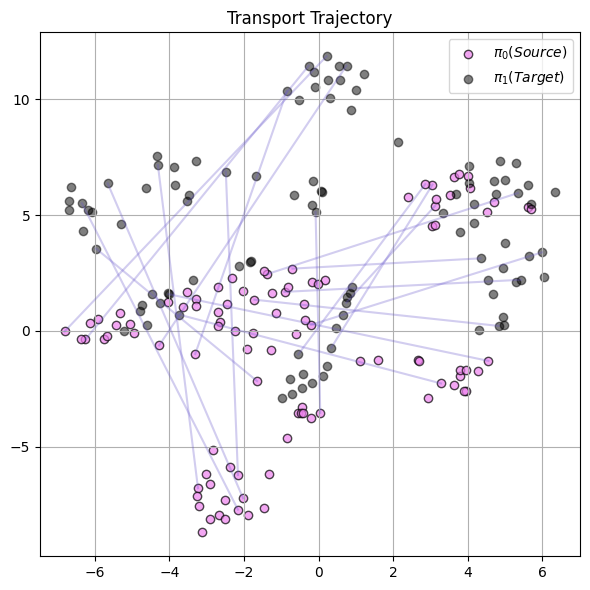

In [115]:
draw_target(X_tsne, Y_tsne, traj_plot=20)

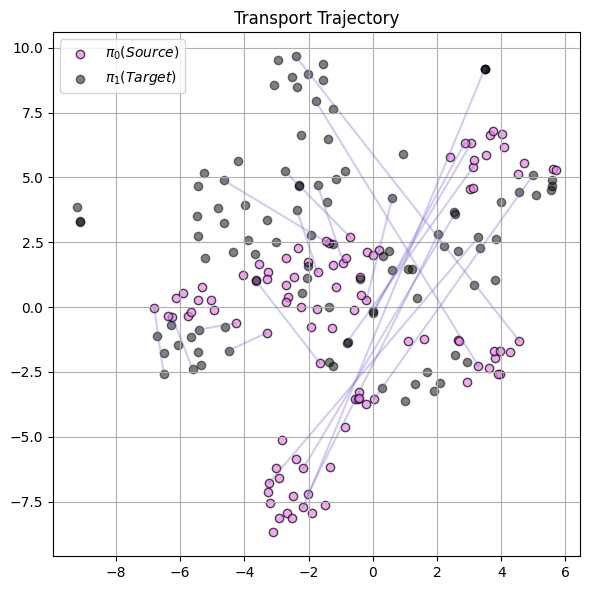

In [116]:
draw_target(X_tsne, T_tsne, traj_plot=20)